# Contact-distance decay by cell type (Fig 4A,B, S24B)

Part of the **[Fig. 4 chapter](fig4.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}clustering/merged/5kCG100k3C_summary.h5ad'`  ·  _joint summary obj_
- `f'{outdir}decay/cell_*_decay.hdf5'`  ·  _other_
- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `'/gale/netapp/home/wtian/hba/analysis/MultiModalityIntigration/RNA/vs-DNAm/integration-data/neu.majortype-transfered-from-mC.pdpkl'`  ·  _other_
- `'/gale/netapp/home/wtian/hba/analysis/MultiModalityIntigration/RNA/vs-DNAm/integration-data/nonn.majortype-transfered-from-mC.pdpkl'`  ·  _other_
- `'/gale/netapp/home/wtian/hba/analysis/MultiModalityIntigration/RNA/clustering/based-on-kim-20220729/cell_meta.qced.pdhdf'`  ·  _metadata_
- `'/gale/netapp/home/wtian/hba/analysis/MotifEnrich/MajorType/dmr.MajorType.rho08.dist250.filter1.repflt/qry.h5ad'`  ·  _DMR_
- `f'/gale/netapp/home/wtian/hba/analysis/DMR/DMR-results/MajorType-hyp/hypo.{xx}.bed'`  ·  _DMR_
- `f'{indir}compartment_majortype/saddle_impute_mergerawpca.npy'`  ·  _compartment_
- `f'{indir}compartment_majortype/saddle_raw_mergerawpca.npy'`  ·  _compartment_
- `f'{cemba.CEMBA_SNM3C_CELL_TYPE_ANNOTATION_PATH}/CEMBA.snm3C.Annotations.zarr/'`  ·  _ext: CEMBA_
- `f'{indir}cell_*_decay.hdf5'`  ·  _other_


In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
from glob import glob
import time
from scipy.stats import spearmanr, pearsonr
from itertools import cycle, islice

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'


In [3]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{ENTEX_ROOT}/analysis/'


In [4]:
meta = anndata.read_h5ad(f'{indir}clustering/merged/5kCG100k3C_summary.h5ad').obs
# meta['L1'] = meta['L1'].astype(str)
# meta.loc[meta['L1']=='c7', 'L1'] = 'c35'
# meta.loc[(meta['L1']=='c35') & meta['L2_any'].isin(['c0','c10','c11']), 'L1'] = 'c36'


In [5]:
decay = pd.concat([pd.read_hdf(xx, key='data') for xx in glob(f'{outdir}decay/cell_*_decay.hdf5')], axis=0)
decay = decay.loc[meta.index]
decay = decay / decay.sum(axis=1).values[:,None]


In [6]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_meta = L1_meta.drop(['c35','c36'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color = L1_meta['color'].to_dict()
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name


In [7]:
meta['short'] = decay.loc[:, (decay.columns > 50) & (decay.columns < 78)].mean(axis=1)
meta['long'] = decay.loc[:, (decay.columns > 95) & (decay.columns < 123)].mean(axis=1)
meta['ratio'] = np.log2(meta['short'] / meta['long'])


In [8]:
leg = meta.groupby('L1')['ratio'].median().sort_values().index[::-1]
selc = []
for xx in leg:
    tmp = meta.loc[meta['L1']==xx]
    selc.append(tmp.sort_values('ratio').index[::-1])
    
selc = np.concatenate(selc)
meta = meta.loc[selc]
decay = decay.loc[selc]


In [9]:
offset = [0]
count = meta['L1'].value_counts()
for xx in leg:
    offset.append(offset[-1]+count.loc[xx])

offset = np.array(offset)


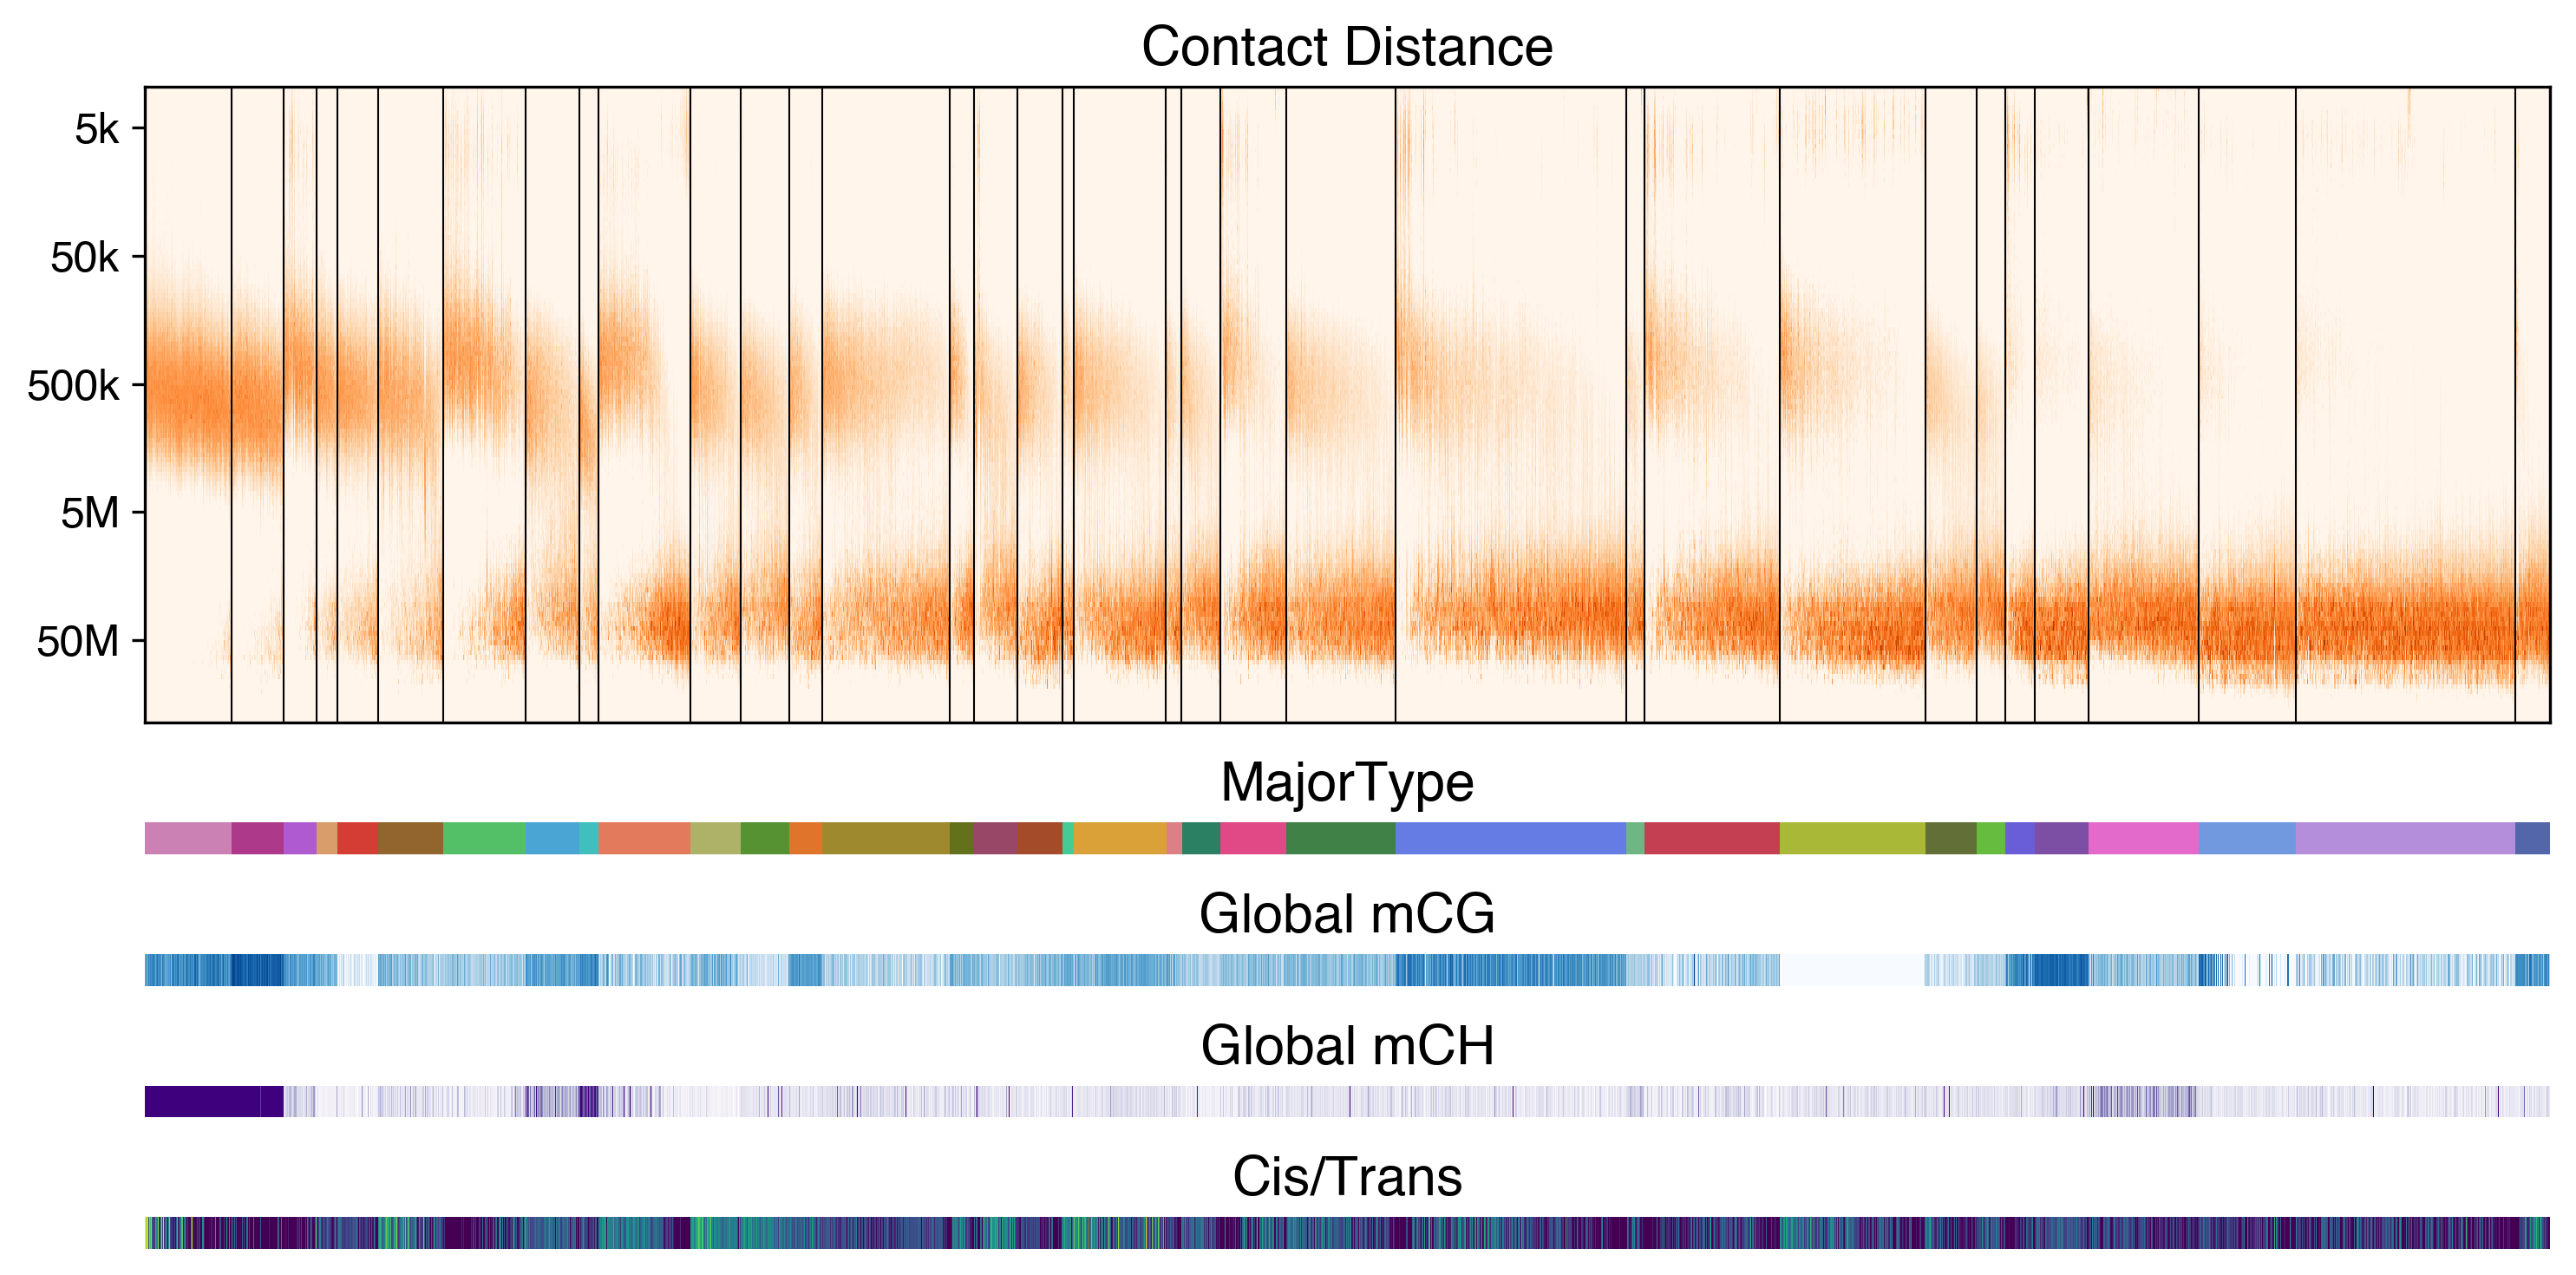

In [10]:
import matplotlib.patches as patches
from scipy.stats import zscore

fig, axes = plt.subplots(5, 1, gridspec_kw={'height_ratios': [20,1,1,1,1]}, figsize=(10,5), sharex='all', dpi=300)
ax = axes[0]
ax.imshow(zscore(decay, axis=1).T, cmap='Oranges', vmin=0, vmax=4, 
          aspect='auto', interpolation='none', rasterized=True)
ax.set_xticks([])
xticks = [5000, 50000, 500000, 5000000, 50000000]
xticklabels = ['5k', '50k', '500k', '5M', '50M']
ax.set_yticks([np.log2(xx/2500)/0.125 for xx in xticks])
ax.set_yticklabels(xticklabels, fontsize=12)
for xx in offset:
    ax.vlines(x=xx-0.5, colors='k', ymin=-0.5, ymax=decay.shape[1]-0.5, linewidths=0.5)

ax = axes[1]
ax.axis('off')
# ax.set_ylabel('MajorType', rotation=0)
for i,xx in enumerate(leg):
    rect = patches.Rectangle((offset[i], 0), offset[i+1]-offset[i], 1, linewidth=0, edgecolor='none', facecolor=L1_color[xx])
    ax.add_patch(rect)
    # ax.text(np.mean(offset[i:(i+2)]), -0.2, label, rotation=90, fontsize=10, horizontalalignment='left', verticalalignment='top')

ax = axes[2]
ax.imshow(meta['mCGFrac'].values[None, :], aspect='auto', vmin=0.65, vmax=0.85, 
          interpolation='none', cmap='Blues', rasterized=True)
ax.axis('off')

ax = axes[3]
ax.imshow(meta['mCHFrac'].values[None, :], aspect='auto', vmin=0.005, vmax=0.025, 
          interpolation='none', cmap='Purples', rasterized=True)
ax.axis('off')

ax = axes[4]
ax.imshow(np.log2(meta['Cis/Trans'].values[None, :]), aspect='auto', vmin=0, vmax=1.5, 
          interpolation='none', cmap='viridis', rasterized=True)
ax.axis('off')

for ax,xx in zip(axes, ['Contact Distance', 'MajorType', 'Global mCG', 'Global mCH', 'Cis/Trans']):
    ax.set_title(xx, fontsize=15)

plt.tight_layout()
plt.savefig(f'decay/cell_{meta.shape[0]}_majortype_decay.pdf', transparent=True, dpi=300)



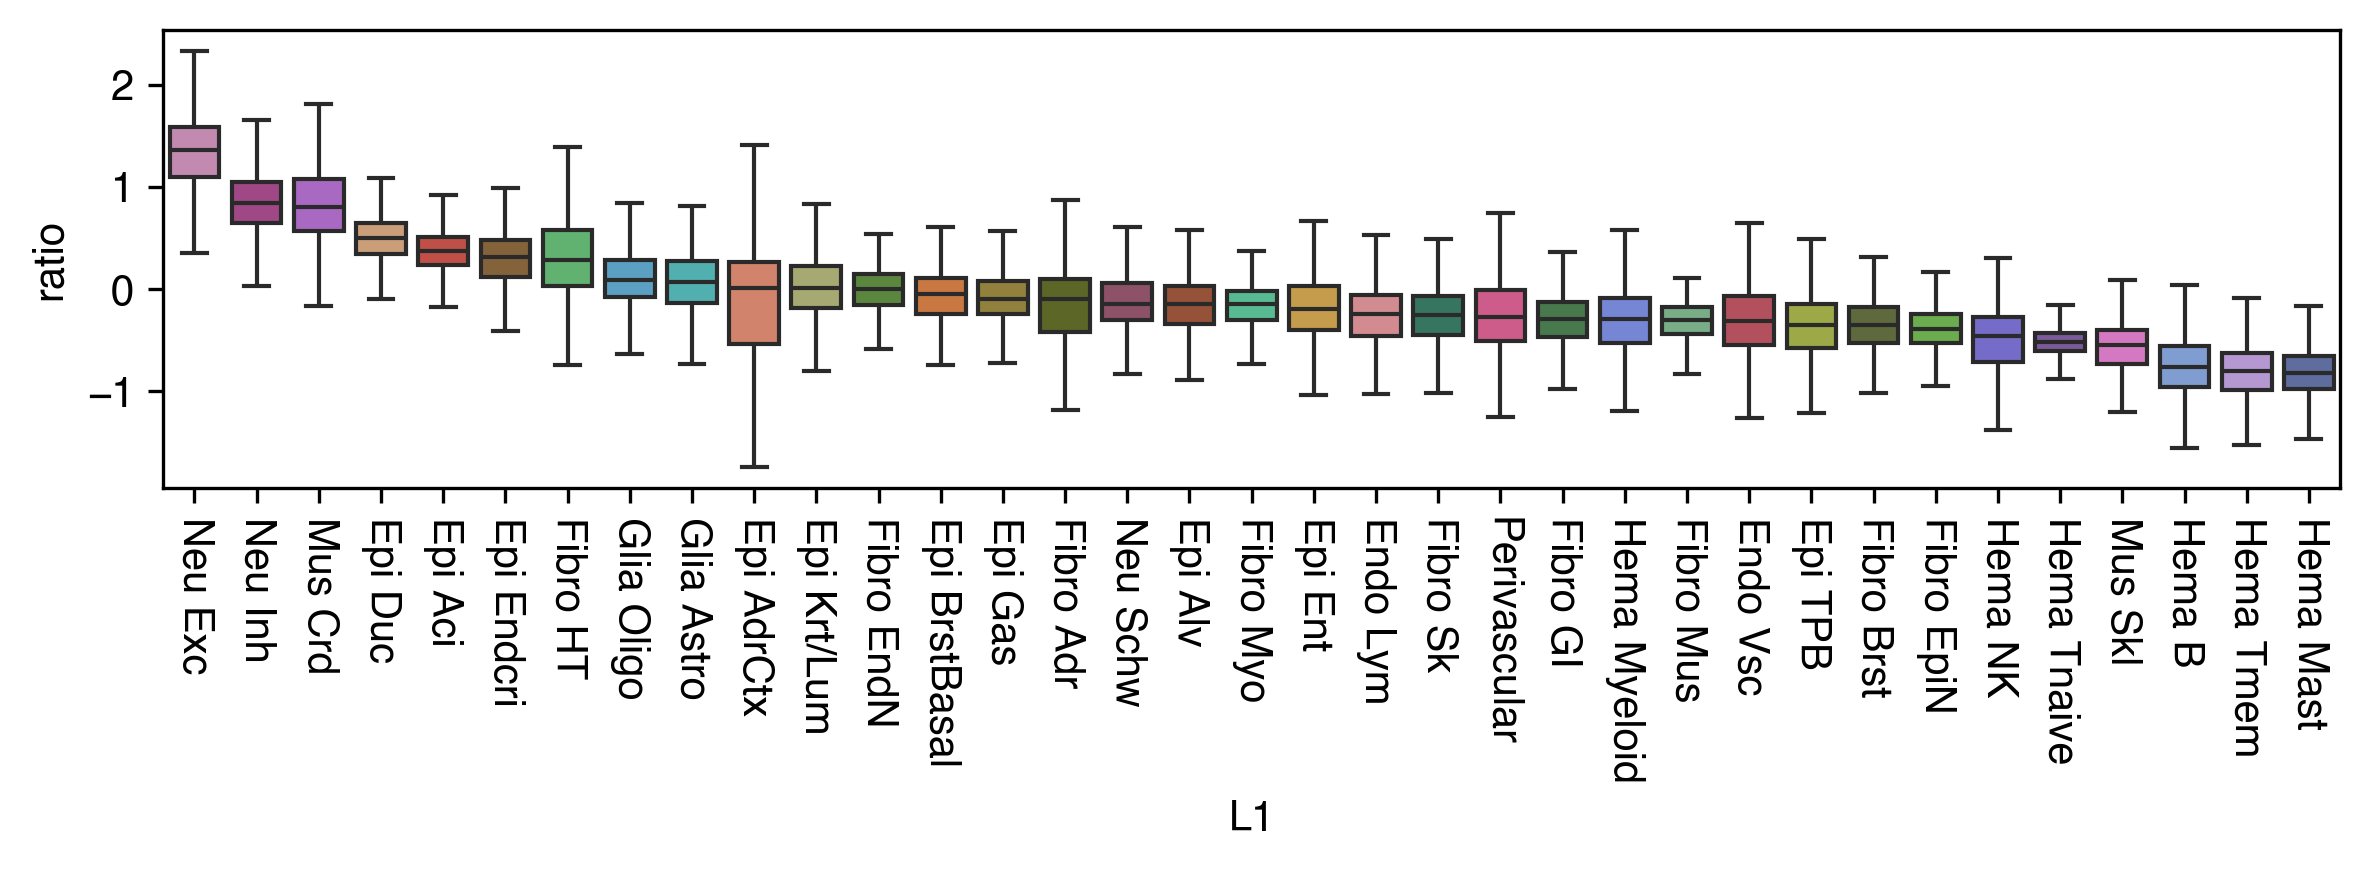

In [11]:
fig, ax = plt.subplots(figsize=(8,3), dpi=300)
sns.boxplot(data=meta, x='L1', y='ratio', order=leg, ax=ax, palette=L1_color, showfliers=False)
ax.set_xticklabels([L1_annot[xx] for xx in leg], rotation=-90)
plt.tight_layout()
plt.savefig(f'decay/cell_{meta.shape[0]}_majortype_decay_boxplot.pdf', transparent=True)


## Liu 2021